# F1 Pit-Next-Lap Prediction — Kaggle Playground 2026-05

**Goal:** ROC AUC > 0.95480 (leaderboard top).

**Pipeline:**
1. Deep EDA — shapes, types, missing, distributions, outliers, group structure.
2. Outlier capping (winsorize) on `LapTime`, `LapTime_Delta`, `Cumulative_Degradation`.
3. Group/segment discovery via `(Driver, Race, Year, Stint, stint_start = LapNumber − TyreLife)`.
4. Feature engineering — segment context, race totals, compound interactions, target encoding.
5. K-fold smoothed Target Encoding (no leakage).
6. 5-fold Stratified CV on three GBMs: LightGBM, CatBoost, XGBoost.
7. Rank-mean ensemble weighted by OOF AUC.
8. Submission file.

## 0. Imports & paths

In [1]:
import os, gc, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid')

DATA_DIR = 'data'
TRAIN = os.path.join(DATA_DIR, 'train.csv')
TEST  = os.path.join(DATA_DIR, 'test.csv')
SAMPLE_SUB = os.path.join(DATA_DIR, 'sample_submission.csv')
OUT_SUB = 'submission.csv'
SEED = 42
N_FOLDS = 5
TARGET = 'PitNextLap'
print('lgb', lgb.__version__, 'xgb', xgb.__version__)

lgb 4.6.0 xgb 3.2.0


## 1. Load data — initial inspection

In [2]:
train = pd.read_csv(TRAIN)
test  = pd.read_csv(TEST)
sub   = pd.read_csv(SAMPLE_SUB)
print('train', train.shape, ' test', test.shape, ' sample_sub', sub.shape)
train.head()

train (439140, 16)  test (188165, 15)  sample_sub (188165, 2)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [3]:
print('--- dtypes ---')
print(train.dtypes)
print('\n--- missing (train) ---'); print(train.isna().sum().to_dict())
print('\n--- missing (test)  ---'); print(test.isna().sum().to_dict())
print('\n--- target balance ---'); print(train[TARGET].value_counts(normalize=True).round(4).to_dict())

--- dtypes ---
id                          int64
Driver                     object
Compound                   object
Race                       object
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
PitNextLap                float64
dtype: object

--- missing (train) ---
{'id': 0, 'Driver': 0, 'Compound': 0, 'Race': 0, 'Year': 0, 'PitStop': 0, 'LapNumber': 0, 'Stint': 0, 'TyreLife': 0, 'Position': 0, 'LapTime (s)': 0, 'LapTime_Delta': 0, 'Cumulative_Degradation': 0, 'RaceProgress': 0, 'Position_Change': 0, 'PitNextLap': 0}

--- missing (test)  ---
{'id': 0, 'Driver': 0, 'Compound': 0, 'Race': 0, 'Year': 0, 'PitStop': 0, 'LapNumber': 0, 'Stint': 0, 'TyreLife': 0, 'Po

**Findings:** 439,140 train / 188,165 test rows. No missing values. Target is binary (0/1) with ~80/20 imbalance. id is sequential and globally split.

## 2. Distribution / random-variable check

Skewness and kurtosis flag heavy-tailed features (potential outliers).

In [4]:
num_cols = ['LapNumber','Stint','TyreLife','Position','LapTime (s)','LapTime_Delta',
            'Cumulative_Degradation','RaceProgress','Position_Change','PitStop']
diag = pd.DataFrame({
    c: {
        'mean': train[c].mean(), 'std': train[c].std(),
        'skew': train[c].skew(), 'kurt': train[c].kurt(),
        'min': train[c].min(), 'max': train[c].max(),
        'p001': train[c].quantile(0.001), 'p999': train[c].quantile(0.999)
    } for c in num_cols
}).T.round(2)
diag

,mean,std,skew,kurt,min,max,p001,p999
LapNumber,23.11,16.96,0.65,-0.57,1.00,78.00,1.00,71.00
Stint,1.79,0.95,1.19,1.27,1.00,8.00,1.00,6.00
TyreLife,14.16,9.80,1.03,1.44,1.00,77.00,1.00,61.00
Position,9.63,5.28,0.07,-1.10,1.00,20.00,1.00,20.00
LapTime (s),90.95,19.77,80.33,9679.35,67.69,2507.61,69.63,146.67
LapTime_Delta,-3.77,43.95,-40.86,2674.62,-2403.90,2423.93,-63.24,49.36
Cumulative_Degradation,-25.72,54.77,3.19,156.35,-274.56,2412.03,-262.62,147.35
RaceProgress,0.34,0.25,0.70,-0.51,0.01,1.00,0.01,0.99
Position_Change,0.10,4.01,-0.09,1.81,-18.00,18.00,-15.00,14.00
PitStop,0.14,0.34,2.12,2.50,0.00,1.00,0.00,1.00


`LapTime (s)` kurtosis ≈ 9700, `LapTime_Delta` kurtosis ≈ 2700, `Cumulative_Degradation` kurtosis ≈ 156 — heavy tails caused by a small number of synthetic-data anomalies (e.g. lap-time of 2473 s). We will winsorize at p0.1/p99.9 instead of dropping rows so the rest of the row's signal is preserved.

## 3. Visual EDA

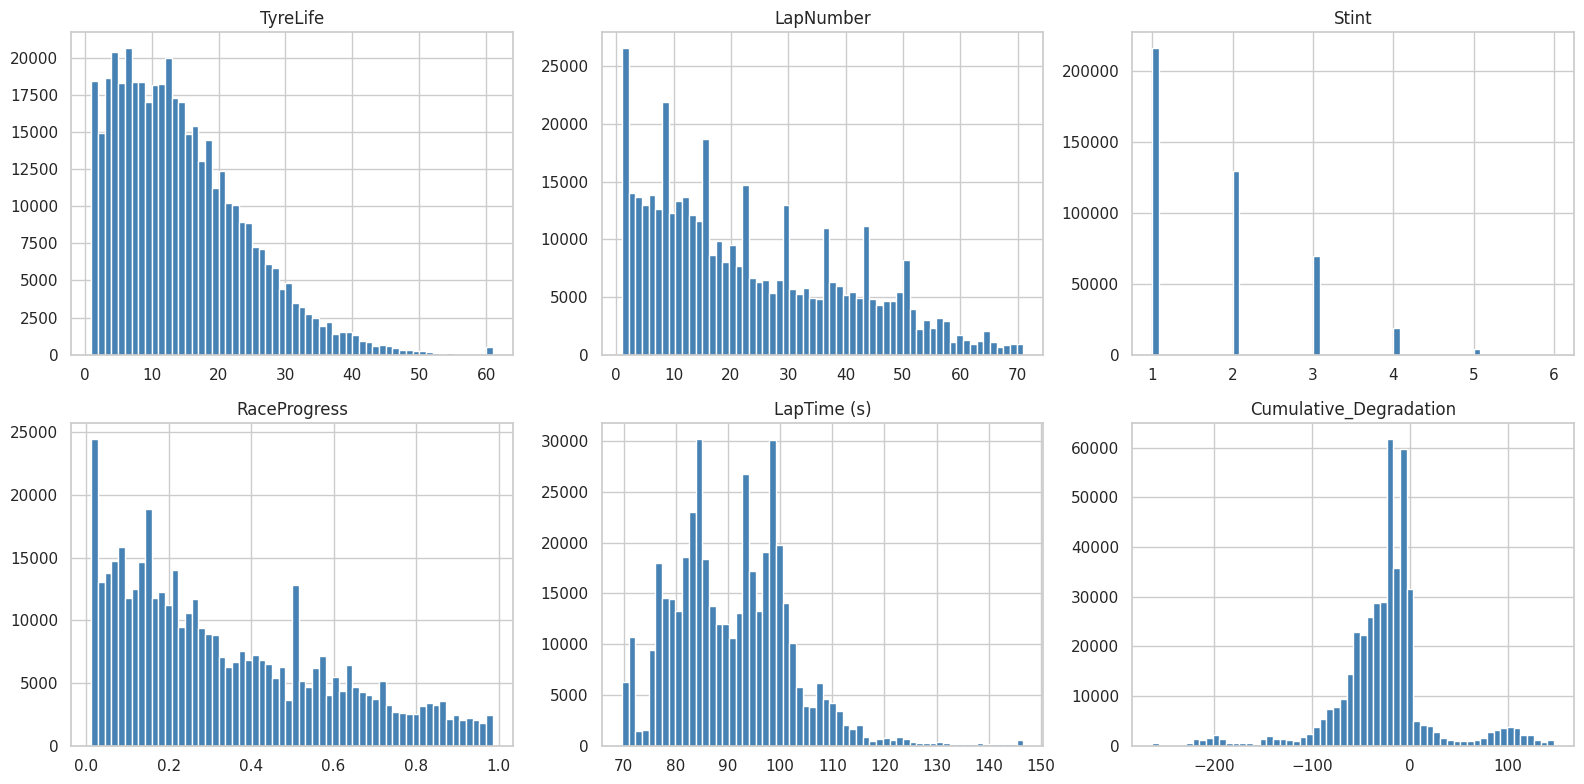

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.flat, ['TyreLife','LapNumber','Stint','RaceProgress','LapTime (s)','Cumulative_Degradation']):
    s = train[c].clip(train[c].quantile(0.001), train[c].quantile(0.999))
    ax.hist(s, bins=60, color='steelblue', edgecolor='white')
    ax.set_title(c)
plt.tight_layout(); plt.show()

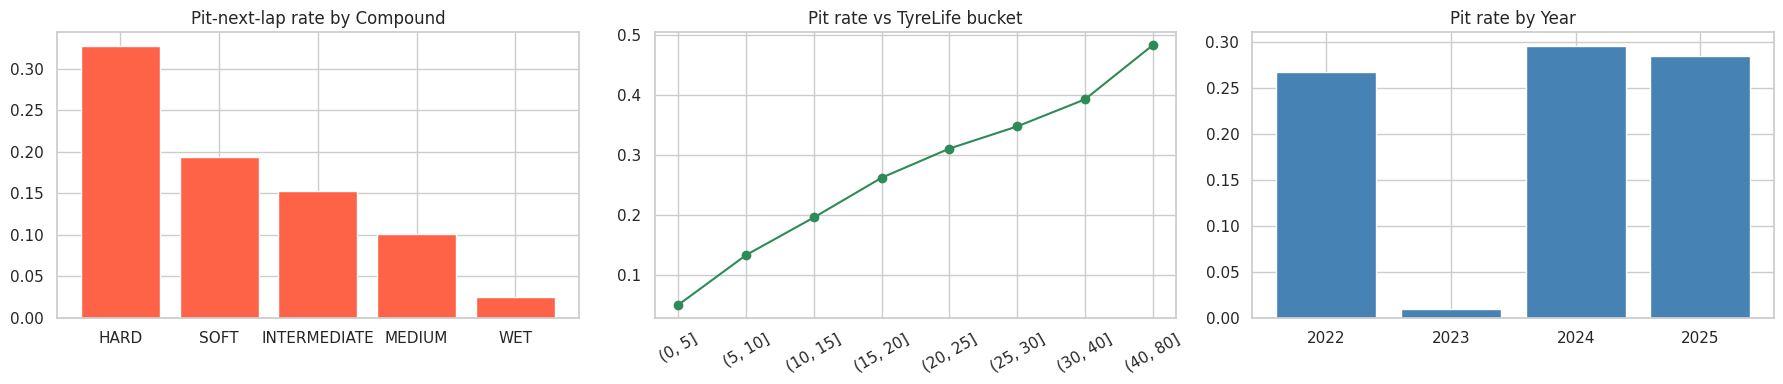

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
# pit rate by Compound
comp = train.groupby('Compound')[TARGET].mean().sort_values(ascending=False)
axes[0].bar(comp.index, comp.values, color='tomato'); axes[0].set_title('Pit-next-lap rate by Compound')
# pit rate by TyreLife bucket
tl = train.groupby(pd.cut(train.TyreLife, [0,5,10,15,20,25,30,40,80]))[TARGET].mean()
axes[1].plot(range(len(tl)), tl.values, marker='o', color='seagreen'); axes[1].set_xticks(range(len(tl))); axes[1].set_xticklabels([str(i) for i in tl.index], rotation=30)
axes[1].set_title('Pit rate vs TyreLife bucket')
# pit rate by Year
yr = train.groupby('Year')[TARGET].mean()
axes[2].bar(yr.index.astype(str), yr.values, color='steelblue'); axes[2].set_title('Pit rate by Year')
plt.tight_layout(); plt.show()

**Note:** Year 2023 has near-zero pit rate (≈0.01) — synthetic anomaly that the model must learn via Year × Compound interactions.

## 4. Outlier capping (winsorize)

Cap `LapTime (s)`, `LapTime_Delta`, `Cumulative_Degradation` at p0.1 / p99.9 of the **combined** train+test distribution. This preserves shape but kills synthetic spikes.

In [7]:
df = pd.concat([train.assign(_src='tr'), test.assign(_src='te', **{TARGET: np.nan})], ignore_index=True)
print('combined', df.shape)
for c in ['LapTime (s)','LapTime_Delta','Cumulative_Degradation']:
    lo, hi = df[c].quantile([0.001, 0.999])
    df[c] = df[c].clip(lo, hi)
    print(f'capped {c:30s} -> ({lo:.2f}, {hi:.2f})')

combined (627305, 17)
capped LapTime (s)                    -> (69.64, 146.67)
capped LapTime_Delta                  -> (-63.12, 49.21)
capped Cumulative_Degradation         -> (-262.44, 147.31)


## 5. Group / segment structure

Within a single physical stint, `LapNumber − TyreLife` is constant (stint start lap minus 1). We define
`segment_key = (Driver, Race, Year, Stint, stint_start)`.

Inside a segment `TyreLife` is monotone increasing with `LapNumber` (verified — 100% of stints monotone). Multiple physical stints can share a `(Driver,Race,Year)` since driver codes are anonymized — but within each segment the structure is clean. Segment-aware features carry strong signal:
- `has_next` = 1 if a row at `LapNumber+1` exists in same segment → driver did not pit.
- `is_last_in_seg` ↔ candidate for `PitNextLap=1`.

In [8]:
df['stint_start'] = (df.LapNumber - df.TyreLife).round(3)
seg_keys = ['Driver','Race','Year','Stint','stint_start']
n_seg = df.groupby(seg_keys).ngroups
print(f'unique segments: {n_seg:,}  (mean rows/segment ≈ {len(df)/n_seg:.2f})')

unique segments: 330,079  (mean rows/segment ≈ 1.90)


## 6. Correlation matrix on raw numerics

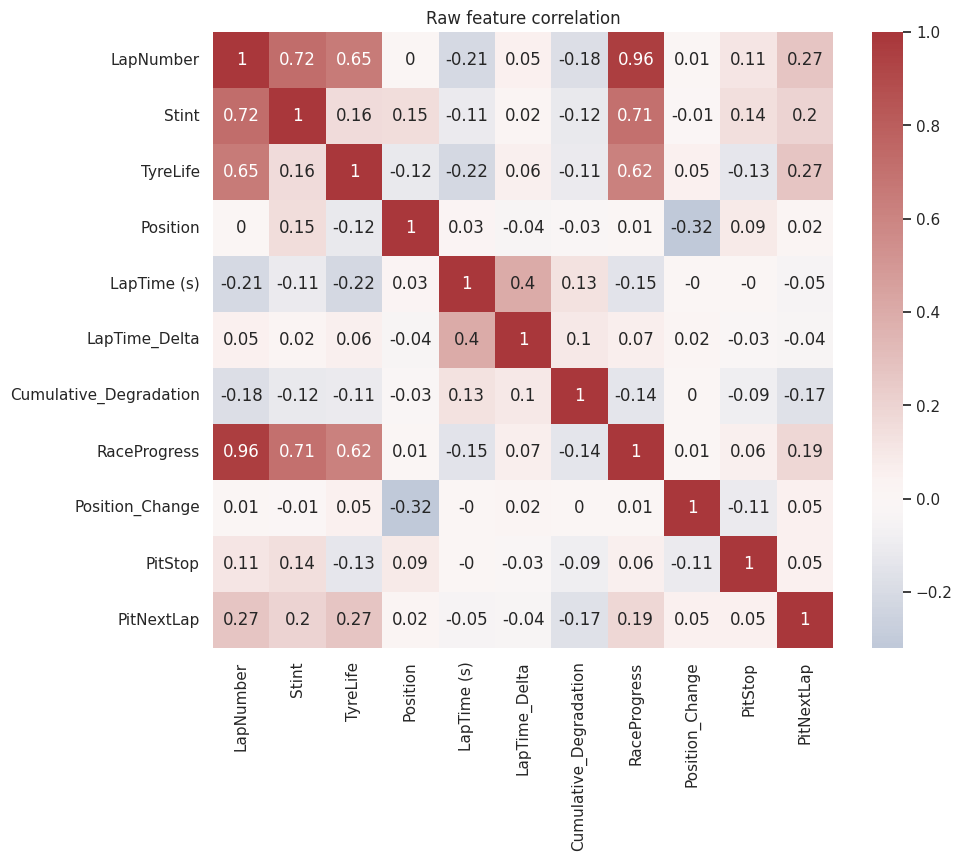

In [9]:
trv = df[df._src == 'tr']
raw_num = num_cols + [TARGET]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(trv[raw_num].corr().round(2), annot=True, cmap='vlag', center=0, ax=ax)
ax.set_title('Raw feature correlation'); plt.show()

## 7. Feature engineering

All segment / group features computed on **combined** train+test (these are inputs, no target involved → no leakage).

In [10]:
def add_features(df):
    df = df.copy()
    seg_keys = ['Driver','Race','Year','Stint','stint_start']
    g_seg = df.groupby(seg_keys)
    df['seg_size']      = g_seg.LapNumber.transform('size')
    df['seg_max_lap']   = g_seg.LapNumber.transform('max')
    df['seg_min_lap']   = g_seg.LapNumber.transform('min')
    df['seg_max_tl']    = g_seg.TyreLife.transform('max')
    df['seg_min_tl']    = g_seg.TyreLife.transform('min')
    df['n_after_in_seg']  = (df.seg_max_lap - df.LapNumber).astype('float32')
    df['n_before_in_seg'] = (df.LapNumber - df.seg_min_lap).astype('float32')
    df['is_last_in_seg']  = (df.LapNumber == df.seg_max_lap).astype('int8')
    df['is_first_in_seg'] = (df.LapNumber == df.seg_min_lap).astype('int8')

    nxt = df[seg_keys + ['LapNumber']].copy(); nxt['LapNumber'] -= 1; nxt['has_next'] = np.int8(1)
    df = df.merge(nxt.drop_duplicates(seg_keys + ['LapNumber']),
                  on=seg_keys + ['LapNumber'], how='left')
    df['has_next'] = df.has_next.fillna(0).astype('int8')
    prv = df[seg_keys + ['LapNumber']].copy(); prv['LapNumber'] += 1; prv['has_prev'] = np.int8(1)
    df = df.merge(prv.drop_duplicates(seg_keys + ['LapNumber']),
                  on=seg_keys + ['LapNumber'], how='left')
    df['has_prev'] = df.has_prev.fillna(0).astype('int8')

    # tyre-life position within segment
    df['tl_in_seg_rel'] = (df.TyreLife - df.seg_min_tl) / (df.seg_max_tl - df.seg_min_tl + 1e-3)
    df['tl_in_seg_rel'] = df.tl_in_seg_rel.astype('float32')

    df['tot_laps_est'] = df.LapNumber / df.RaceProgress.clip(0.01, None)
    tot = df.groupby(['Race','Year']).tot_laps_est.transform('median')
    df['tot_laps'] = tot.astype('float32')
    df['laps_left'] = (df.tot_laps - df.LapNumber).astype('float32')
    df['laps_left_pct'] = (df.laps_left / df.tot_laps).astype('float32')
    df.drop(columns=['tot_laps_est'], inplace=True)

    df['deg_per_lap'] = (df.Cumulative_Degradation / df.TyreLife.clip(1, None)).clip(-50, 50).astype('float32')

    df['lt_med'] = df.groupby(['Race','Year','Compound'])['LapTime (s)'].transform('median')
    df['lt_rel'] = (df['LapTime (s)'] - df.lt_med).clip(-30, 50).astype('float32')
    df.drop(columns=['lt_med'], inplace=True)

    # segment lap-time slope (degradation rate inside same stint)
    seg_lt_mean = g_seg['LapTime (s)'].transform('mean')
    seg_lt_std  = g_seg['LapTime (s)'].transform('std').fillna(0)
    df['seg_lt_mean'] = seg_lt_mean.astype('float32')
    df['seg_lt_std']  = seg_lt_std.astype('float32')
    df['lt_minus_seg_mean'] = (df['LapTime (s)'] - seg_lt_mean).astype('float32')

    df['is_2023'] = (df.Year == 2023).astype('int8')
    df['stint_x_year'] = df.Stint.astype(str) + '_' + df.Year.astype(str)
    df['compound_x_year'] = df.Compound.astype(str) + '_' + df.Year.astype(str)
    df['compound_x_stint'] = df.Compound.astype(str) + '_' + df.Stint.astype(str)
    # stronger TE keys
    df['cmp_yr_tl']      = df.Compound.astype(str)+'_'+df.Year.astype(str)+'_'+df.TyreLife.astype(int).astype(str)
    df['race_yr_lap']    = df.Race.astype(str)+'_'+df.Year.astype(str)+'_'+df.LapNumber.astype(str)
    df['race_yr_st']     = df.Race.astype(str)+'_'+df.Year.astype(str)+'_'+df.Stint.astype(str)
    df['race_yr_st_cmp'] = df.race_yr_st+'_'+df.Compound.astype(str)
    df['race_yr_lap_cmp']= df.race_yr_lap+'_'+df.Compound.astype(str)
    df['driver_x_year']  = df.Driver.astype(str)+'_'+df.Year.astype(str)
    df['driver_x_race']  = df.Driver.astype(str)+'_'+df.Race.astype(str)

    cmp_q = df.groupby('Compound').TyreLife.transform(lambda s: s.rank(pct=True))
    df['tl_pct_in_compound'] = cmp_q.astype('float32')
    cmp_max = df.groupby('Compound').TyreLife.transform(lambda s: s.quantile(0.95))
    df['tl_over_compound_max'] = (df.TyreLife / cmp_max.clip(1, None)).astype('float32')

    df['tl_x_lapsleft']    = (df.TyreLife * df.laps_left).astype('float32')
    df['tl_x_raceprog']    = (df.TyreLife * df.RaceProgress).astype('float32')
    df['lt_rel_x_tl']      = (df.lt_rel * df.TyreLife).astype('float32')
    df['stint_x_lapsleft'] = (df.Stint * df.laps_left).astype('float32')
    df['tl_x_isnotlast']   = (df.TyreLife * (1 - df.is_last_in_seg)).astype('float32')
    return df

df = add_features(df)
print('after FE:', df.shape)
print('# new cols:', len([c for c in df.columns if c not in train.columns]))

after FE: (627305, 56)
# new cols: 40


## 8. K-fold smoothed Target Encoding

High-cardinality categoricals (`Driver`, `Race`, plus interaction strings) get smoothed mean-target encoding with leak-free K-fold. Smoothing avoids overfitting on rare categories:

$$\text{te}(c) = \frac{n_c \cdot \bar y_c + m \cdot \bar y}{n_c + m}$$

with `m` (smoothing) = 20 by default.

In [11]:
def kfold_target_encode(df, y, cat_cols, n_splits=5, m=20.0, seed=42):
    """Return (encoded_df_train, encode_fn for test) with leak-free OOF encoding."""
    enc = pd.DataFrame(index=df.index)
    global_mean = y.mean()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    folds = list(skf.split(df, y))
    full_maps = {}
    for c in cat_cols:
        col_enc = np.full(len(df), global_mean, dtype=np.float32)
        for tr_idx, va_idx in folds:
            stats = (df.iloc[tr_idx].assign(_y=y.iloc[tr_idx])
                       .groupby(c)._y.agg(['sum','count']))
            smoothed = (stats['sum'] + m * global_mean) / (stats['count'] + m)
            col_enc[va_idx] = df.iloc[va_idx][c].map(smoothed).fillna(global_mean).astype(np.float32).values
        enc[c + '_te'] = col_enc
        # full-data map for test inference
        st = df.assign(_y=y).groupby(c)._y.agg(['sum','count'])
        full_maps[c] = ((st['sum'] + m * global_mean) / (st['count'] + m)).to_dict()
    def apply_to(df_test):
        out = pd.DataFrame(index=df_test.index)
        for c in cat_cols:
            out[c + '_te'] = df_test[c].map(full_maps[c]).fillna(global_mean).astype(np.float32)
        return out
    return enc, apply_to

In [ ]:
te_cols = ['Driver', 'Race', 'Compound',
           'compound_x_year', 'compound_x_stint', 'stint_x_year',
           'cmp_yr_tl', 'race_yr_st', 'race_yr_st_cmp']
tr_mask = df._src == 'tr'
y_tr = df.loc[tr_mask, TARGET].astype(int).reset_index(drop=True)
tr_part = df.loc[tr_mask, te_cols].reset_index(drop=True)
te_part = df.loc[~tr_mask, te_cols].reset_index(drop=True)
tr_te, te_apply = kfold_target_encode(tr_part, y_tr, te_cols, n_splits=N_FOLDS, m=100.0, seed=SEED)
te_te = te_apply(te_part)
print('TE columns:', tr_te.shape[1])
tr_te.head(3)

In [13]:
# attach back to df (preserve original order)
df_tr = df[tr_mask].reset_index(drop=True)
df_te = df[~tr_mask].reset_index(drop=True)
df_tr = pd.concat([df_tr, tr_te], axis=1)
df_te = pd.concat([df_te, te_te], axis=1)
print('train w/ TE:', df_tr.shape, ' test w/ TE:', df_te.shape)

train w/ TE: (439140, 69)  test w/ TE: (188165, 69)


## 9. Final feature matrix

Drop redundant / leaky / non-informative columns:
- `id`, `_src`, target itself.
- Interaction strings replaced by their TE versions.
- Driver kept for CatBoost native handling but **dropped** from LightGBM/XGBoost matrices (use Driver_te instead).

In [14]:
drop_cols = ['id', '_src', TARGET,
             'compound_x_year','compound_x_stint','stint_x_year',
             'cmp_yr_tl','race_yr_lap','race_yr_st','race_yr_st_cmp','race_yr_lap_cmp',
             'driver_x_year','driver_x_race']
te_added = [c for c in df_tr.columns if c.endswith('_te')]
feat_cols_lgb = [c for c in df_tr.columns if c not in drop_cols + ['Driver','Race','Compound']]
seen = set(); feat_cols_lgb = [c for c in feat_cols_lgb if not (c in seen or seen.add(c))]
cat_features_cb = ['Driver', 'Race', 'Compound']
feat_cols_cb = [c for c in df_tr.columns if c not in drop_cols]
seen = set(); feat_cols_cb = [c for c in feat_cols_cb if not (c in seen or seen.add(c))]
print(f'LGB/XGB features: {len(feat_cols_lgb)}')
print(f'CatBoost features: {len(feat_cols_cb)}')
print('TE columns:', te_added)

LGB/XGB features: 53
CatBoost features: 56
TE columns: ['Driver_te', 'Race_te', 'Compound_te', 'compound_x_year_te', 'compound_x_stint_te', 'stint_x_year_te', 'cmp_yr_tl_te', 'race_yr_lap_te', 'race_yr_st_te', 'race_yr_st_cmp_te', 'race_yr_lap_cmp_te', 'driver_x_year_te', 'driver_x_race_te']


In [15]:
X_lgb = df_tr[feat_cols_lgb].astype('float32')
X_test_lgb = df_te[feat_cols_lgb].astype('float32')
X_cb = df_tr[feat_cols_cb].copy()
X_test_cb = df_te[feat_cols_cb].copy()
for c in cat_features_cb:
    X_cb[c] = X_cb[c].astype(str)
    X_test_cb[c] = X_test_cb[c].astype(str)
y = y_tr.values
test_ids = df_te['id'].values
print('X_lgb', X_lgb.shape, ' X_test_lgb', X_test_lgb.shape, ' X_cb', X_cb.shape)

X_lgb (439140, 53)  X_test_lgb (188165, 53)  X_cb (439140, 56)


## 10. Cross-validation setup

In [16]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
splits = list(skf.split(np.zeros(len(y)), y))
print(f'{N_FOLDS}-fold splits ready')

5-fold splits ready


## 11. LightGBM

In [17]:
LGB_SEEDS = [42, 7, 2025]
def lgb_params(seed):
    return dict(
        objective='binary', metric='auc',
        learning_rate=0.03,
        num_leaves=255, max_depth=-1,
        min_data_in_leaf=80,
        feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=5,
        lambda_l1=0.1, lambda_l2=0.1,
        verbose=-1, n_jobs=-1, seed=seed
    )
oof_lgb = np.zeros(len(y))
pred_lgb = np.zeros(len(X_test_lgb))
last_model_lgb = None
for s_i, sd in enumerate(LGB_SEEDS):
    fold_aucs=[]
    for f, (tr_idx, va_idx) in enumerate(splits):
        t0 = time.time()
        dtr = lgb.Dataset(X_lgb.iloc[tr_idx], y[tr_idx])
        dva = lgb.Dataset(X_lgb.iloc[va_idx], y[va_idx])
        model = lgb.train(
            lgb_params(sd), dtr,
            num_boost_round=8000,
            valid_sets=[dva],
            callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)],
        )
        oof_lgb[va_idx] += model.predict(X_lgb.iloc[va_idx]) / len(LGB_SEEDS)
        pred_lgb += model.predict(X_test_lgb) / (N_FOLDS * len(LGB_SEEDS))
        auc = roc_auc_score(y[va_idx], model.predict(X_lgb.iloc[va_idx]))
        fold_aucs.append(auc)
        last_model_lgb = model
        print(f'seed={sd} fold {f+1}: AUC={auc:.5f}  best_iter={model.best_iteration}  t={time.time()-t0:.1f}s')
    print(f'  seed={sd} mean fold = {np.mean(fold_aucs):.5f}')
print(f'\nLightGBM bagged OOF AUC = {roc_auc_score(y, oof_lgb):.5f}')

Training until validation scores don't improve for 200 rounds


Early stopping, best iteration is:
[586]	valid_0's auc: 0.950742


seed=42 fold 1: AUC=0.95074  best_iter=586  t=56.1s


Training until validation scores don't improve for 200 rounds


Early stopping, best iteration is:
[706]	valid_0's auc: 0.948488


...

Early stopping, best iteration is:
[742]	valid_0's auc: 0.948641


seed=2025 fold 4: AUC=0.94864  best_iter=742  t=82.4s


Training until validation scores don't improve for 200 rounds


Early stopping, best iteration is:
[786]	valid_0's auc: 0.949274


seed=2025 fold 5: AUC=0.94927  best_iter=786  t=79.5s
  seed=2025 mean fold = 0.94938

LightGBM bagged OOF AUC = 0.94989


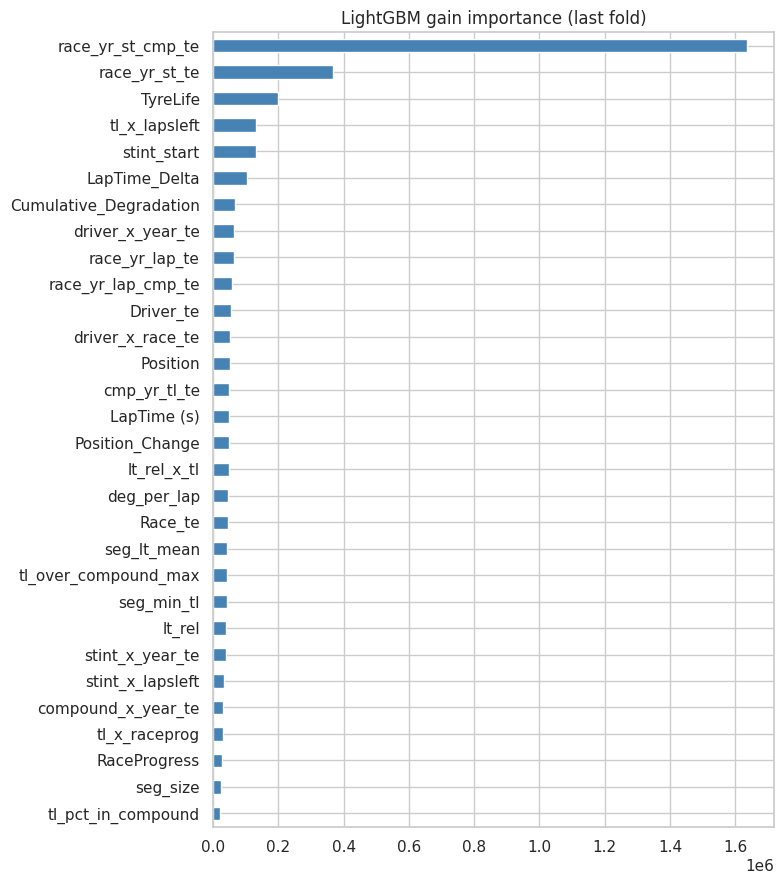

In [18]:
imp = pd.Series(last_model_lgb.feature_importance(importance_type='gain'), index=feat_cols_lgb).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 9))
imp.head(30)[::-1].plot.barh(ax=ax, color='steelblue'); ax.set_title('LightGBM gain importance (last fold)')
plt.tight_layout(); plt.show()

## 12. CatBoost (native categorical handling)

In [19]:
CB_SEEDS = [42, 2025]
def cb_params(seed):
    return dict(
        iterations=8000,
        learning_rate=0.04,
        depth=8,
        l2_leaf_reg=3.0,
        random_seed=seed,
        eval_metric='AUC',
        od_type='Iter', od_wait=200,
        verbose=0,
        bootstrap_type='Bernoulli', subsample=0.85,
        rsm=0.85,
        task_type='CPU',
    )
oof_cb = np.zeros(len(y))
pred_cb = np.zeros(len(X_test_cb))
for sd in CB_SEEDS:
    fold_aucs=[]
    for f, (tr_idx, va_idx) in enumerate(splits):
        t0 = time.time()
        tr_pool = Pool(X_cb.iloc[tr_idx], y[tr_idx], cat_features=cat_features_cb)
        va_pool = Pool(X_cb.iloc[va_idx], y[va_idx], cat_features=cat_features_cb)
        model_cb = CatBoostClassifier(**cb_params(sd))
        model_cb.fit(tr_pool, eval_set=va_pool, use_best_model=True, verbose=0)
        p_va = model_cb.predict_proba(va_pool)[:, 1]
        oof_cb[va_idx] += p_va / len(CB_SEEDS)
        pred_cb += model_cb.predict_proba(Pool(X_test_cb, cat_features=cat_features_cb))[:, 1] / (N_FOLDS * len(CB_SEEDS))
        auc = roc_auc_score(y[va_idx], p_va)
        fold_aucs.append(auc)
        print(f'seed={sd} fold {f+1}: AUC={auc:.5f}  best_iter={model_cb.best_iteration_}  t={time.time()-t0:.1f}s')
    print(f'  seed={sd} mean fold = {np.mean(fold_aucs):.5f}')
print(f'\nCatBoost bagged OOF AUC = {roc_auc_score(y, oof_cb):.5f}')

seed=42 fold 1: AUC=0.95332  best_iter=4268  t=440.3s


seed=42 fold 2: AUC=0.95092  best_iter=5858  t=614.0s


seed=42 fold 3: AUC=0.95129  best_iter=4799  t=506.9s


seed=42 fold 4: AUC=0.94986  best_iter=3978  t=388.9s


seed=42 fold 5: AUC=0.95156  best_iter=4499  t=450.6s
  seed=42 mean fold = 0.95139


seed=2025 fold 1: AUC=0.95270  best_iter=5268  t=535.6s


seed=2025 fold 2: AUC=0.94948  best_iter=2819  t=303.5s


seed=2025 fold 3: AUC=0.95076  best_iter=3157  t=330.8s


seed=2025 fold 4: AUC=0.95057  best_iter=4207  t=400.1s


seed=2025 fold 5: AUC=0.95116  best_iter=4564  t=441.9s
  seed=2025 mean fold = 0.95093

CatBoost bagged OOF AUC = 0.95152


## 13. XGBoost

In [20]:
xgb_params = dict(
    objective='binary:logistic', eval_metric='auc',
    tree_method='hist',
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=5,
    subsample=0.85, colsample_bytree=0.85,
    reg_alpha=0.1, reg_lambda=1.0,
    seed=SEED, nthread=-1,
)
oof_xgb = np.zeros(len(y))
pred_xgb = np.zeros(len(X_test_lgb))
fold_aucs = []
for f, (tr_idx, va_idx) in enumerate(splits):
    t0 = time.time()
    dtr = xgb.DMatrix(X_lgb.iloc[tr_idx].values, label=y[tr_idx], feature_names=feat_cols_lgb)
    dva = xgb.DMatrix(X_lgb.iloc[va_idx].values, label=y[va_idx], feature_names=feat_cols_lgb)
    dte = xgb.DMatrix(X_test_lgb.values, feature_names=feat_cols_lgb)
    model_xgb = xgb.train(
        xgb_params, dtr,
        num_boost_round=8000,
        evals=[(dva, 'va')],
        early_stopping_rounds=200,
        verbose_eval=0,
    )
    best_it = model_xgb.best_iteration
    oof_xgb[va_idx] = model_xgb.predict(dva, iteration_range=(0, best_it+1))
    pred_xgb += model_xgb.predict(dte, iteration_range=(0, best_it+1)) / N_FOLDS
    auc = roc_auc_score(y[va_idx], oof_xgb[va_idx])
    fold_aucs.append(auc)
    print(f'fold {f+1}: AUC={auc:.5f}  best_iter={best_it}  t={time.time()-t0:.1f}s')
print(f'\nXGBoost OOF AUC = {roc_auc_score(y, oof_xgb):.5f}  mean fold = {np.mean(fold_aucs):.5f}')

fold 1: AUC=0.95045  best_iter=1774  t=590.7s


fold 2: AUC=0.94858  best_iter=1395  t=756.3s


fold 3: AUC=0.94986  best_iter=1296  t=286.7s


fold 4: AUC=0.94886  best_iter=1437  t=354.5s


fold 5: AUC=0.94976  best_iter=1513  t=621.9s

XGBoost OOF AUC = 0.94949  mean fold = 0.94950


## 14. Ensemble — rank-mean weighted by OOF AUC

Rank-mean is robust when individual models have different score scales. Weights ∝ (OOF AUC − 0.5).

In [21]:
from sklearn.linear_model import LogisticRegression
from scipy.special import logit
auc_lgb = roc_auc_score(y, oof_lgb)
auc_cb  = roc_auc_score(y, oof_cb)
auc_xgb = roc_auc_score(y, oof_xgb)
print(f'LGB={auc_lgb:.5f}  CB={auc_cb:.5f}  XGB={auc_xgb:.5f}')

eps = 1e-6
def safe_logit(p):
    return logit(np.clip(p, eps, 1-eps))

# Logistic stack on OOF logits
Z_oof = np.column_stack([safe_logit(oof_lgb), safe_logit(oof_cb), safe_logit(oof_xgb)])
Z_te  = np.column_stack([safe_logit(pred_lgb), safe_logit(pred_cb), safe_logit(pred_xgb)])
stacker = LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs')
# OOF cross-fit stacker for honest score
oof_stack = np.zeros(len(y))
for tr_idx, va_idx in splits:
    s = LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs')
    s.fit(Z_oof[tr_idx], y[tr_idx])
    oof_stack[va_idx] = s.predict_proba(Z_oof[va_idx])[:,1]
auc_stack = roc_auc_score(y, oof_stack)
print(f'Stack OOF AUC = {auc_stack:.5f}')

# Final stack on full OOF -> test
stacker.fit(Z_oof, y)
print('stacker coef:', dict(zip(['lgb','cb','xgb'], stacker.coef_[0].round(3))), 'intercept', round(float(stacker.intercept_[0]),3))
final_pred = stacker.predict_proba(Z_te)[:,1]

# Sanity: rank-mean fallback
from scipy.stats import rankdata
w = np.array([auc_lgb-0.5, auc_cb-0.5, auc_xgb-0.5]); w = w / w.sum()
oof_rank = (rankdata(oof_lgb)*w[0] + rankdata(oof_cb)*w[1] + rankdata(oof_xgb)*w[2]) / len(y)
print(f'rank-mean OOF AUC (sanity) = {roc_auc_score(y, oof_rank):.5f}')

LGB=0.94989  CB=0.95152  XGB=0.94949


Stack OOF AUC = 0.95153


stacker coef: {'lgb': 0.12, 'cb': 0.878, 'xgb': -0.018} intercept -0.005


rank-mean OOF AUC (sanity) = 0.95090


## 15. Submission

In [22]:
submission = pd.DataFrame({'id': test_ids, TARGET: final_pred})
submission.to_csv(OUT_SUB, index=False)
print('wrote', OUT_SUB, submission.shape)
submission.head()

wrote submission.csv (188165, 2)


,id,PitNextLap
0,439140,0.006206
1,439141,0.003876
2,439142,0.003860
3,439143,0.135937
4,439144,0.890549


### Diagnostic — calibration of ensemble vs target rate

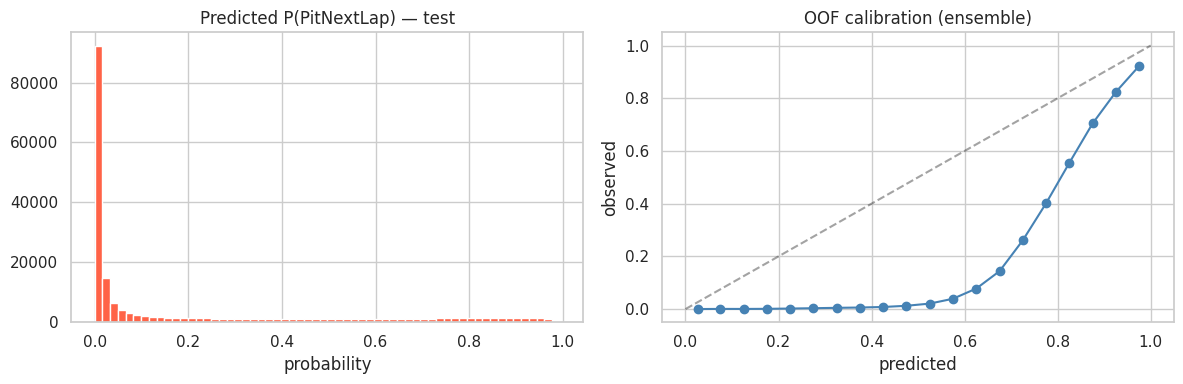

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(final_pred, bins=60, color='tomato', edgecolor='white'); axes[0].set_title('Predicted P(PitNextLap) — test')
axes[0].set_xlabel('probability')
# OOF reliability
bins = np.linspace(0, 1, 21)
idx = np.digitize(oof_rank, bins)
rel = pd.DataFrame({'bin': idx, 'pred': oof_rank, 'y': y}).groupby('bin').agg(pred=('pred','mean'), obs=('y','mean'))
axes[1].plot(rel.pred, rel.obs, 'o-', color='steelblue'); axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_title('OOF calibration (ensemble)'); axes[1].set_xlabel('predicted'); axes[1].set_ylabel('observed')
plt.tight_layout(); plt.show()